In [42]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller
from scipy.stats import boxcox
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error



In [43]:
dataframe = pd.read_csv("/Users/v/Data Science Projects/time-series-project/data/original/retail_sales_mock_data.csv")


what needs to be done for ML models:

* cleaning of the features to ensure integrity
* feature engieering to create new aggregate features (rolling mean etc)
* creating lag features to allow for regression models to be able to learn and model 'time'



check data integrity 

In [44]:
dataframe.info()
#need to convert the columns with dates to datetime 

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Date          48 non-null     str  
 1   SalesAmount   48 non-null     int64
 2   Promotion     48 non-null     int64
 3   HolidayMonth  48 non-null     int64
dtypes: int64(3), str(1)
memory usage: 1.6 KB


In [45]:
dataframe.head()

,Date,SalesAmount,Promotion,HolidayMonth
0,2020-01-01,12248,0,0
1,2020-02-01,13011,0,0
2,2020-03-01,12722,0,0
3,2020-04-01,14030,1,0
4,2020-05-01,7783,0,0


In [46]:
dataframe.index

RangeIndex(start=0, stop=48, step=1)

In [47]:
dataframe[dataframe.duplicated()]
dataframe.duplicated().sum()
#no duplicates

np.int64(0)

In [48]:

dataframe["Date"] = pd.to_datetime(dataframe["Date"])
dataframe = dataframe.set_index("Date")

In [49]:
dataframe2 = dataframe.columns.drop(['SalesAmount'])
dataframe['SalesAmount'].dtype

dtype('int64')

In [50]:
print(type(dataframe.index))

<class 'pandas.DatetimeIndex'>


In [51]:
dataframe.head()

,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0


In [52]:
dataframe.index.is_monotonic_increasing

True

In [53]:
dataframe = dataframe.asfreq("MS")
print(dataframe.index.freq)
dataframe.head()

<MonthBegin>


,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0


In [54]:
dataframe.isna().sum()

SalesAmount     0
Promotion       0
HolidayMonth    0
dtype: int64

In [55]:
dataframe['SalesAmount'].describe()
print(dataframe["SalesAmount"].skew())
print(dataframe["SalesAmount"].kurtosis())

0.3906054459092882
0.16477248984587556


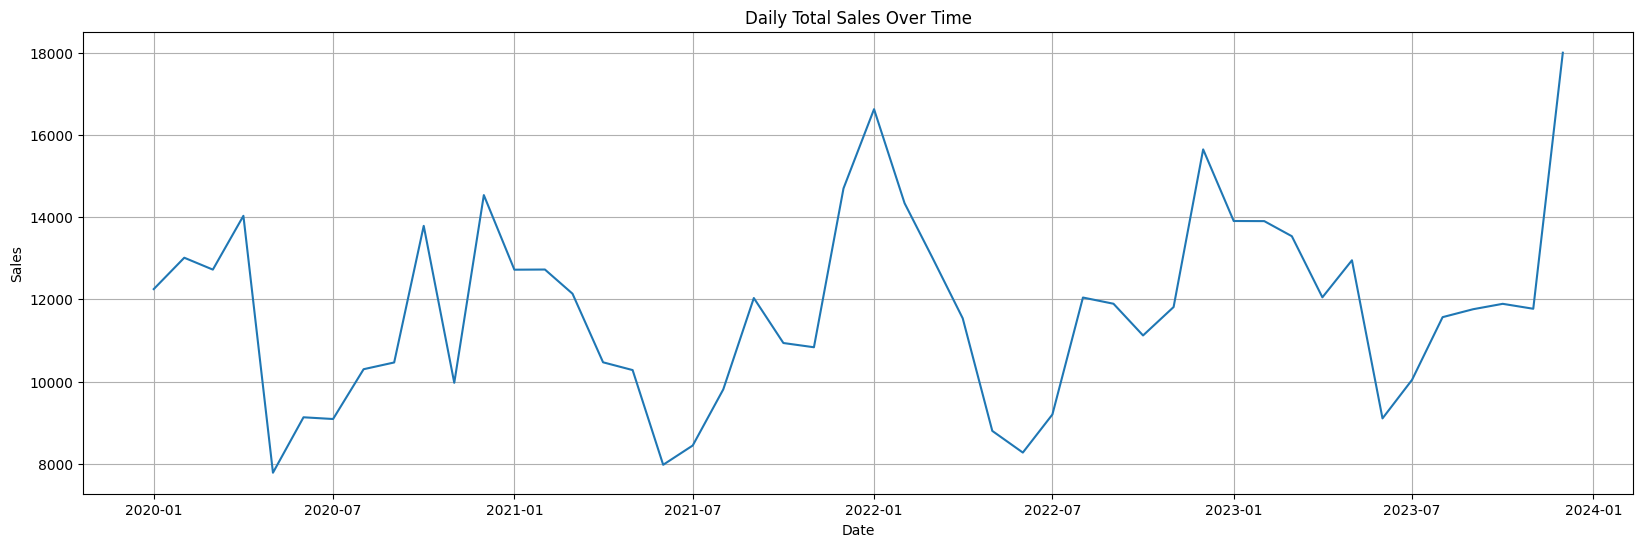

In [56]:
plt.figure(figsize=(20,6))
plt.plot(dataframe.index, dataframe['SalesAmount'])
plt.title("Daily Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()


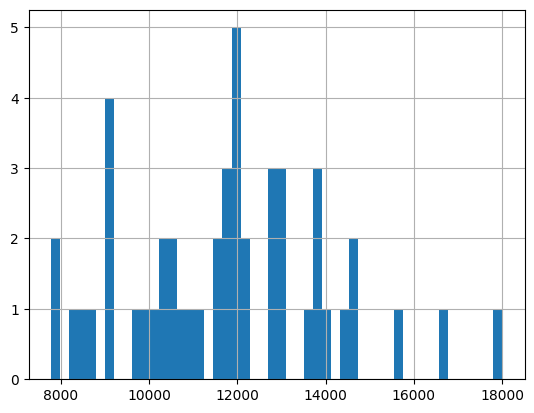

In [57]:
dataframe["SalesAmount"].hist(bins=50)
plt.show()

<Axes: xlabel='SalesAmount'>

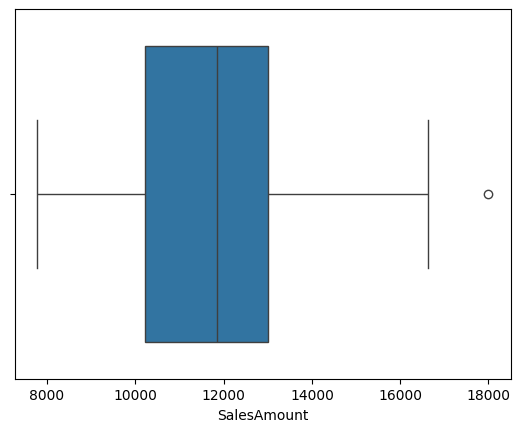

In [58]:
import seaborn as sns
sns.boxplot(x=dataframe["SalesAmount"])

<Axes: xlabel='month'>

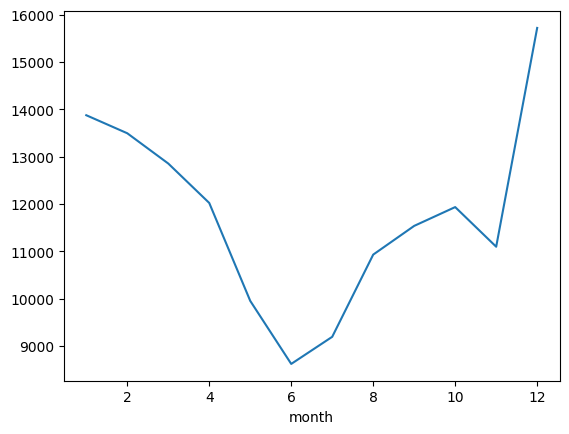

In [59]:
dataframe["month"] = dataframe.index.month

dataframe.groupby("month")["SalesAmount"].mean().plot()


<Axes: xlabel='month', ylabel='SalesAmount'>

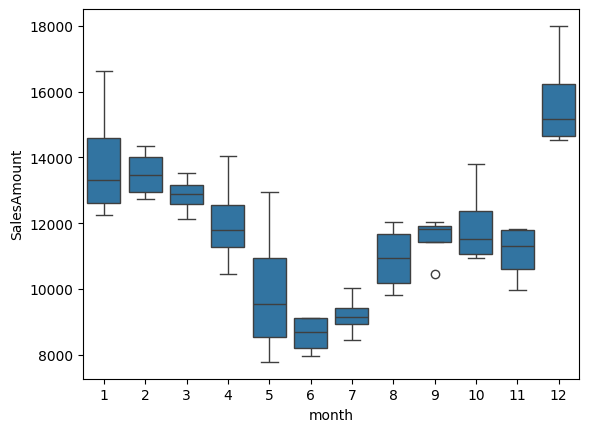

In [60]:
sns.boxplot(x=dataframe["month"], y=dataframe["SalesAmount"], data=dataframe)

In [61]:
def adf_test(series):
    """ADF test for stationarity"""

    test_results = adfuller(series.dropna())

    print('ADF Statistic:', test_results[0])
    print('P-Value:', test_results[1])
    print('Critical Values:')

    for thres, adf_stat in test_results[4].items():
        print(f'\t{thres}: {adf_stat:.2f}')

adf_test(dataframe['SalesAmount'])

ADF Statistic: -4.514183597733958
P-Value: 0.00018535586430261367
Critical Values:
	1%: -3.60
	5%: -2.93
	10%: -2.60


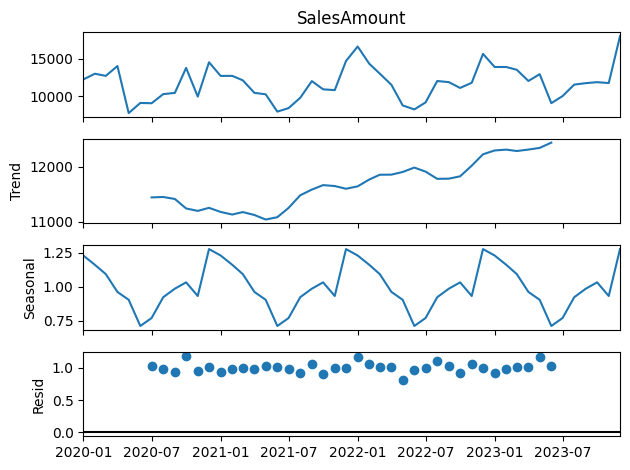

1.0008383731246566


In [62]:
#decompose the series
#i can see that there is clearly seasonaality roughly a trend and seasonality but i should still decompose to inspect it
decomposition_plot_multi = seasonal_decompose(dataframe['SalesAmount'], model= 'multiplicative')
decomposition_plot_multi.plot()
plt. show()
print(np.mean(decomposition_plot_multi.resid))

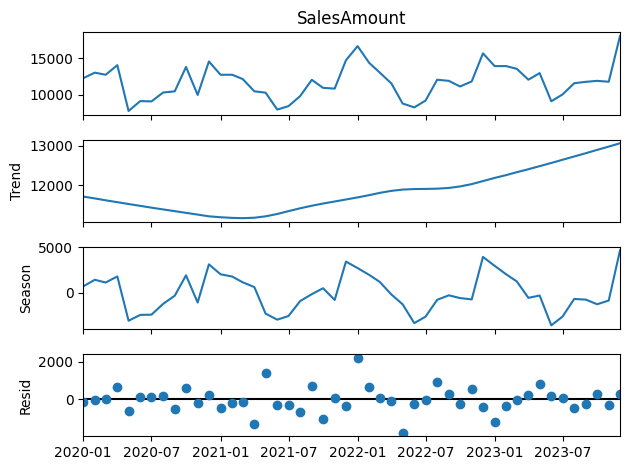

mean:  11768.541666666666
std:  2233.9049979644515
resid mean:  -24.17640292086753


In [63]:
stl = STL(dataframe['SalesAmount'], period=12)
result = stl.fit()
result.plot()
plt.show()
np.mean(result.resid)
print('mean: ',np.mean(dataframe['SalesAmount']))
print('std: ',np.std(dataframe['SalesAmount']))
print('resid mean: ',np.mean(result.resid))

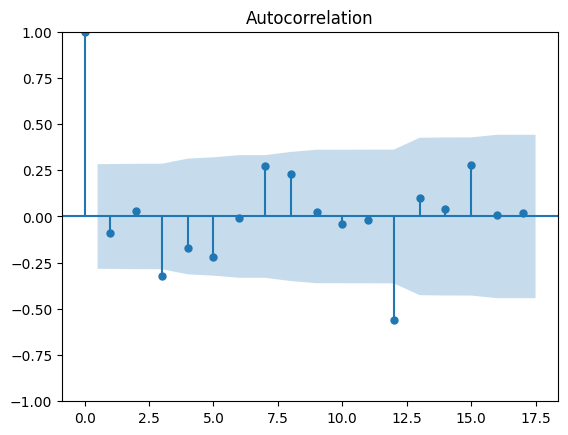

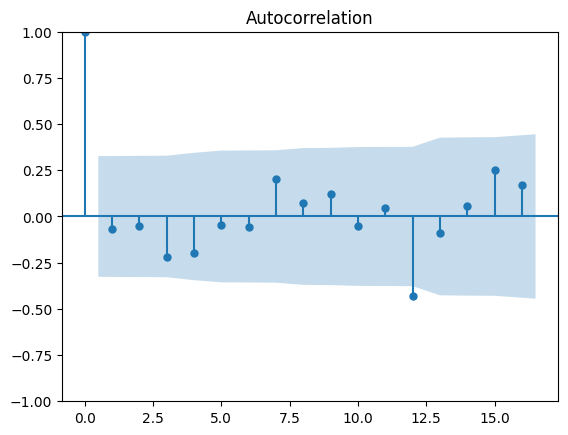

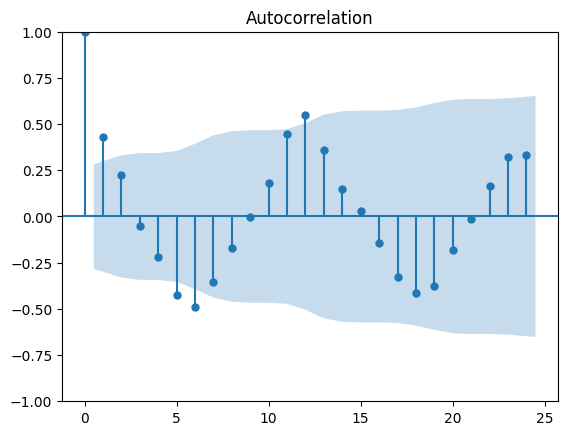

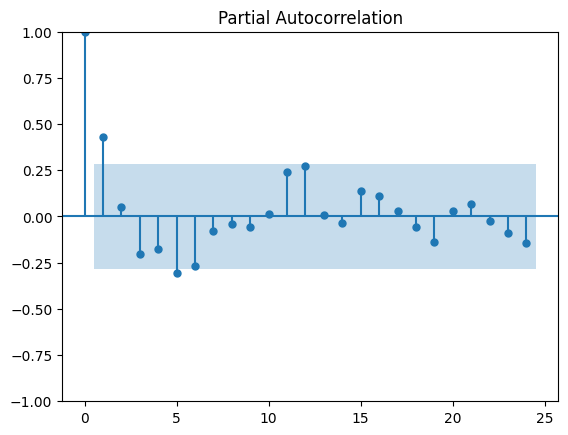

In [64]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot1 = plot_acf(result.resid.dropna())
plot2 = plot_acf(decomposition_plot_multi.resid.dropna())
plot3 = plot_acf(dataframe["SalesAmount"], lags=24)
plot4 = plot_pacf(dataframe["SalesAmount"], lags=24)
plt.show()

<Axes: xlabel='Date'>

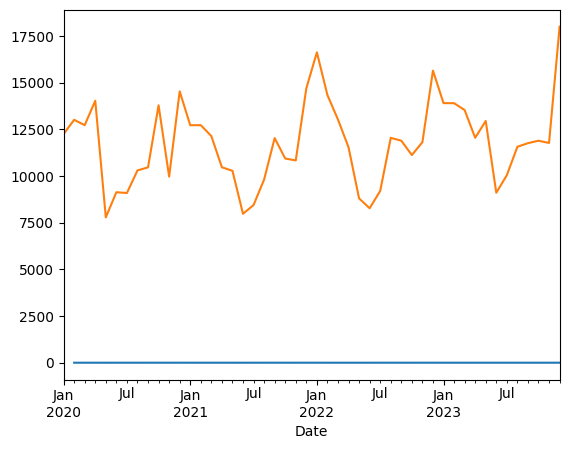

In [65]:
#check stationailty
log_data = np.log(dataframe['SalesAmount'])
log_diff_data = log_data.diff()
log_diff_data.plot()
dataframe['SalesAmount'].plot()

In [66]:
'''
def adf_test(series):
    """ADF test for stationarity"""

    test_results = adfuller(series.dropna())

    print('ADF Statistic:', test_results[0])
    print('P-Value:', test_results[1])
    print('Critical Values:')

    for thres, adf_stat in test_results[4].items():
        print(f'\t{thres}: {adf_stat:.2f}')

adf_test(monthly_sales)
'''

'\ndef adf_test(series):\n    """ADF test for stationarity"""\n\n    test_results = adfuller(series.dropna())\n\n    print(\'ADF Statistic:\', test_results[0])\n    print(\'P-Value:\', test_results[1])\n    print(\'Critical Values:\')\n\n    for thres, adf_stat in test_results[4].items():\n        print(f\'\t{thres}: {adf_stat:.2f}\')\n\nadf_test(monthly_sales)\n'

In [67]:
'''
#check stationailty
log_data,lam = boxcox(monthly_sales)
log_data = pd.Series(
    log_data,
    index=monthly_sales.index
)
log_diff_data = log_data.diff()
log_diff_data.plot()
print(lam)
'''

'\n#check stationailty\nlog_data,lam = boxcox(monthly_sales)\nlog_data = pd.Series(\n    log_data,\n    index=monthly_sales.index\n)\nlog_diff_data = log_data.diff()\nlog_diff_data.plot()\nprint(lam)\n'

In [68]:
# ADF test
'''

def adf_test(series):
    """ADF test for stationarity"""

    test_results = adfuller(series.dropna())

    print('ADF Statistic:', test_results[0])
    print('P-Value:', test_results[1])
    print('Critical Values:')

    for thres, adf_stat in test_results[4].items():
        print(f'\t{thres}: {adf_stat:.2f}')

adf_test(log_diff_data)
'''


'\n\ndef adf_test(series):\n    """ADF test for stationarity"""\n\n    test_results = adfuller(series.dropna())\n\n    print(\'ADF Statistic:\', test_results[0])\n    print(\'P-Value:\', test_results[1])\n    print(\'Critical Values:\')\n\n    for thres, adf_stat in test_results[4].items():\n        print(f\'\t{thres}: {adf_stat:.2f}\')\n\nadf_test(log_diff_data)\n'

Box-Cox transform is better and should thus be used

data is now stationary

now begin the Autocorrelation analysis: acf and pacf
this is done just to visualise. in the pipeline i will use cross validation to select p and q

**# feature engineering**

create lag features

In [69]:
shifts = [1,5,6]
for i in shifts:
    dataframe[f'lag_{i}']= dataframe['SalesAmount'].shift(i)
print(dataframe.head(8))
#dataframe = dataframe.dropna()
#print(dataframe.head(8))
rolling = [3,6]
for i in rolling:
    dataframe[f'rolling_mean_{i}'] = dataframe["SalesAmount"].shift(1).rolling(i).mean()
    dataframe[f'rolling_std_{i}'] = dataframe["SalesAmount"].shift(1).rolling(i).std()
#print(dataframe.head(20))
#dataframe = dataframe.dropna()
#print(dataframe.head(20))


            SalesAmount  Promotion  HolidayMonth  month    lag_1    lag_5  \
Date                                                                        
2020-01-01        12248          0             0      1      NaN      NaN   
2020-02-01        13011          0             0      2  12248.0      NaN   
2020-03-01        12722          0             0      3  13011.0      NaN   
2020-04-01        14030          1             0      4  12722.0      NaN   
2020-05-01         7783          0             0      5  14030.0      NaN   
2020-06-01         9131          1             0      6   7783.0  12248.0   
2020-07-01         9089          0             0      7   9131.0  13011.0   
2020-08-01        10300          0             0      8   9089.0  12722.0   

              lag_6  
Date                 
2020-01-01      NaN  
2020-02-01      NaN  
2020-03-01      NaN  
2020-04-01      NaN  
2020-05-01      NaN  
2020-06-01      NaN  
2020-07-01  12248.0  
2020-08-01  13011.0  


create rolling features

In [70]:
dataframe.head(13)

,SalesAmount,Promotion,HolidayMonth,month,lag_1,lag_5,lag_6,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6
Date,,,,,,,,,,,
2020-01-01,12248,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-01,13011,0,0,2,12248.0,NaN,NaN,NaN,NaN,NaN,NaN
2020-03-01,12722,0,0,3,13011.0,NaN,NaN,NaN,NaN,NaN,NaN
2020-04-01,14030,1,0,4,12722.0,NaN,NaN,12660.333333,385.219851,NaN,NaN
2020-05-01,7783,0,0,5,14030.0,NaN,NaN,13254.333333,687.113043,NaN,NaN
2020-06-01,9131,1,0,6,7783.0,12248.0,NaN,11511.666667,3294.682433,NaN,NaN
2020-07-01,9089,0,0,7,9131.0,13011.0,12248.0,10314.666667,3287.408148,11487.500000,2456.180836
2020-08-01,10300,0,0,8,9089.0,12722.0,13011.0,8667.666667,766.431558,10961.000000,2595.201341
2020-09-01,10464,0,0,9,10300.0,14030.0,12722.0,9506.666667,687.367684,10509.166667,2395.197313


In [71]:
'''
rolling = [3,5]
for i in rolling:
    dataframe[f'rolling_mean_{i}'] = dataframe["SalesAmount"].shift(1).rolling(i).mean()
    dataframe[f'rolling_std_{i}'] = dataframe["SalesAmount"].shift(1).rolling(i).std()
#print(dataframe.head(20))
dataframe = dataframe.dropna()
#print(dataframe.head(20))
'''

'\nrolling = [3,5]\nfor i in rolling:\n    dataframe[f\'rolling_mean_{i}\'] = dataframe["SalesAmount"].shift(1).rolling(i).mean()\n    dataframe[f\'rolling_std_{i}\'] = dataframe["SalesAmount"].shift(1).rolling(i).std()\n#print(dataframe.head(20))\ndataframe = dataframe.dropna()\n#print(dataframe.head(20))\n'

create calendar features

In [72]:
dataframe['month'] = dataframe.index.month
dataframe['year'] = dataframe.index.year
dataframe['quarter'] = dataframe.index.quarter
dataframe.head()

,SalesAmount,Promotion,HolidayMonth,month,lag_1,lag_5,lag_6,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,year,quarter
Date,,,,,,,,,,,,,
2020-01-01,12248,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020,1
2020-02-01,13011,0,0,2,12248.0,NaN,NaN,NaN,NaN,NaN,NaN,2020,1
2020-03-01,12722,0,0,3,13011.0,NaN,NaN,NaN,NaN,NaN,NaN,2020,1
2020-04-01,14030,1,0,4,12722.0,NaN,NaN,12660.333333,385.219851,NaN,NaN,2020,2
2020-05-01,7783,0,0,5,14030.0,NaN,NaN,13254.333333,687.113043,NaN,NaN,2020,2


drop na rows

In [73]:
dataframe = dataframe.dropna()
dataframe.head()

,SalesAmount,Promotion,HolidayMonth,month,lag_1,lag_5,lag_6,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,year,quarter
Date,,,,,,,,,,,,,
2020-07-01,9089,0,0,7,9131.0,13011.0,12248.0,10314.666667,3287.408148,11487.500000,2456.180836,2020,3
2020-08-01,10300,0,0,8,9089.0,12722.0,13011.0,8667.666667,766.431558,10961.000000,2595.201341,2020,3
2020-09-01,10464,0,0,9,10300.0,14030.0,12722.0,9506.666667,687.367684,10509.166667,2395.197313,2020,3
2020-10-01,13786,1,0,10,10464.0,7783.0,14030.0,9951.000000,751.003995,10132.833333,2141.985006,2020,4
2020-11-01,9969,0,0,11,13786.0,9131.0,7783.0,11516.666667,1967.010252,10092.166667,2053.693981,2020,4


In [74]:
dataframe = dataframe.asfreq("MS")
print(dataframe.index.freq)
dataframe.head()

<MonthBegin>


,SalesAmount,Promotion,HolidayMonth,month,lag_1,lag_5,lag_6,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,year,quarter
Date,,,,,,,,,,,,,
2020-07-01,9089,0,0,7,9131.0,13011.0,12248.0,10314.666667,3287.408148,11487.500000,2456.180836,2020,3
2020-08-01,10300,0,0,8,9089.0,12722.0,13011.0,8667.666667,766.431558,10961.000000,2595.201341,2020,3
2020-09-01,10464,0,0,9,10300.0,14030.0,12722.0,9506.666667,687.367684,10509.166667,2395.197313,2020,3
2020-10-01,13786,1,0,10,10464.0,7783.0,14030.0,9951.000000,751.003995,10132.833333,2141.985006,2020,4
2020-11-01,9969,0,0,11,13786.0,9131.0,7783.0,11516.666667,1967.010252,10092.166667,2053.693981,2020,4


test train split:

Test/train split AFTER feature engineering unlike for tabular data because

Lagged features guarantee:

features(t) subset { data < t }
Even if feature engineering was done on full dataset.

In [75]:
split = int(0.8*len(dataframe))
train_set = dataframe[:split]
test_set = dataframe[split:]


hyperparameter creation

In [76]:
import itertools


def create_param_grid():
        """ create the param grid for cv """
        

        # ---------- Parameter Grid ----------

        max_depth = [3, 5, 7]
        learning_rate = [0.01, 0.05, 0.1]
        n_estimators = [100, 300]

        LightGBM_params = list(itertools.product(max_depth, learning_rate, n_estimators))
        #print(LightGBM_params)

        return LightGBM_params

In [77]:
def create_features(dataframe):

    df = dataframe.copy()

    # Remove previously engineered features first (VERY IMPORTANT)
    feature_prefixes = ('lag_', 'rolling_', 'month', 'year', 'quarter')

    df = df.loc[:, ~df.columns.str.startswith(feature_prefixes)]

    # ----- Lag Features -----
    shifts = [1, 5, 6]

    for i in shifts:
        df[f'lag_{i}'] = df['SalesAmount'].shift(i)

    # ----- Rolling Features -----
    rolling_windows = [3, 6]

    for w in rolling_windows:
        df[f'rolling_mean_{w}'] = df['SalesAmount'].shift(1).rolling(w).mean()
        df[f'rolling_std_{w}'] = df['SalesAmount'].shift(1).rolling(w).std()

    # ----- Calendar Features -----
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['quarter'] = df.index.quarter

    df = df.dropna()

    return df

In [78]:
def cv(train_set,  LightGBM_params):
    

    best_score = np.inf
    best_params = None

    for max_depth, learning_rate, n_estimators in LightGBM_params:
        print('max_depth: ', max_depth)
        print('learning_rate: ', learning_rate)
        print('n_estimators: ', n_estimators)

        score = carry_out_cv(train_set,max_depth, learning_rate, n_estimators)

        print(f"Tested {max_depth}, {learning_rate}, {n_estimators} -> CV Score = {score:.4f}")

        if not np.isnan(score) and score < best_score:
                best_score = score
                best_params = (max_depth, learning_rate, n_estimators)
        
        
        print("\n============================")
        print("BEST MODEL FOUND")
        print("max_depth:", best_params[0])
        print("learning_rate:", best_params[1])
        print("n_estimators:", best_params[2])
        print("CV Score:", best_score)
        print("============================")

    return best_params

        
        
    

def carry_out_cv(train_set, max_depth, learning_rate, n_estimators,threshold=0.8,horizon=3):
    features = train_set.columns.drop(['SalesAmount'])
    target = 'SalesAmount'
    n = len(train_set)
    split = int(threshold * n)
    errors = []
    n_splits = (n - split) // horizon


    #for i in cv folds 
    for i in range(n_splits):
        #window is incrementally increased by the length of horizon until val_end reaches the end of the training set
        window_end = split+(i*horizon)
        val_end = window_end + horizon

        if val_end > n:
            break

        #created the current folds for the cv
        train_subset = train_set.iloc[:window_end]
        val_subset = train_set.iloc[window_end:val_end]

        #created the X and y for the train set
        X_train = train_subset[features]
        y_train = train_subset[target]

        #created the X and y to validate on
        X_val = val_subset[features]
        y_val = val_subset[target]

       #create and fit the model
        model = lgb.LGBMRegressor(n_estimators=n_estimators, learning_rate=learning_rate, max_depth=max_depth)
        model.fit(X_train, y_train)

        # ===== Recursive Forecast =====
        #create a copy of the training fold
        history = train_subset.copy()
        recursive_preds = []

        #for each prediction to compute in this cv interation
        for _ in range(horizon):

            # Rebuild features from history
            #history_featues now contains the lag and rolling features
            history_features = create_features(history.copy())

            #pbtain the most recent observation/entry
                # - only the most recent observation/entry is needed for tree models
                # - given lag and rolling features as the encode history
            X_latest = history_features[features].iloc[[-1]]

            #obtain the prediction as a scaler because it is returned as an np array
            y_pred = model.predict(X_latest)[0]

            #add it to the prediction list
            recursive_preds.append(y_pred)

            #append prediction into history buffer
            new_row = history.iloc[-1:].copy()
            new_row[target] = y_pred

            history = pd.concat([history, new_row])

        # Evaluate recursive forecast vs validation window
        errors.append(
            mean_absolute_error(
                y_val.values,
                recursive_preds
            )
        )
    if len(errors) == 0:
        return float("inf")
        
    return np.mean(errors)

def carry_out_DMS_cv(train_set, max_depth, learning_rate, n_estimators,threshold=0.8,horizon=3):
    features = train_set.columns.drop(['SalesAmount'])
    target = 'SalesAmount'
    n = len(train_set)
    split = int(threshold * n)
    errors = []
    n_splits = (n - split) // horizon

    for i in range(n_splits):
        window_end = split+(i*horizon)
        val_end = window_end + horizon

        if val_end > n:
            break
        train_subset = train_set.iloc[:window_end]
        val_subset = train_set.iloc[window_end:val_end]

        X_train = train_subset[features]
        y_train = train_subset[target]

        X_val = val_subset[features]
        y_val = val_subset[target]

        model = lgb.LGBMRegressor(n_estimators=n_estimators, learning_rate=learning_rate, max_depth=max_depth)
        model.fit(X_train, y_train)

        pred = model.predict(X_val)

        errors.append(
                mean_absolute_error(y_val, pred)
            )
    if len(errors) == 0:
        return float("inf")
        
    return np.mean(errors)


def train_final_model(train_set, max_depth, learning_rate, n_estimators):

    target = 'SalesAmount'
    features = train_set.columns.drop([target])

    X_train = train_set[features]
    y_train = train_set[target]

    model = lgb.LGBMRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth
    )

    model.fit(X_train, y_train)

    return model
     
    



In [79]:
def evaluate_test_set(test_set, model):

    target = 'SalesAmount'
    features = test_set.columns.drop([target])

    X_test = test_set[features]
    y_test = test_set[target]

    pred = model.predict(X_test)

    error = mean_absolute_error(y_test, pred)
    mean_sales = np.mean(y_test)

    return error, pred, mean_sales

In [80]:
def evaluate_test_set_recursive(train_set, test_set, model):

    target = 'SalesAmount'

    # History buffer starts with full training data
    history = train_set.copy()

    recursive_preds = []

    for i in range(len(test_set)):

        # Rebuild features from current history
        history_features = create_features(history.copy())

        # Select latest row (state representation)
        X_latest = history_features.iloc[[-1]].drop(columns=[target], errors='ignore')

        # Predict next step
        y_pred = model.predict(X_latest)[0]
        recursive_preds.append(y_pred)

        # Create new row based on last known row
        new_row = history.iloc[-1:].copy()

        # Replace target with prediction
        new_row[target] = y_pred

        # IMPORTANT: advance time index
        new_row.index = [test_set.index[i]]

        # Append prediction into history
        history = pd.concat([history, new_row])

    # Evaluate against actual test targets
    y_test = test_set[target].values

    assert len(recursive_preds) == len(y_test)

    error = mean_absolute_error(y_test, recursive_preds)
    mean_sales = np.mean(y_test)

    return error, recursive_preds, mean_sales

In [81]:
LightGBM_params = create_param_grid()
max_depth, learning_rate, n_estimators = cv(train_set,  LightGBM_params)
model = train_final_model(train_set, max_depth, learning_rate, n_estimators)
error, pred, mean_sales = evaluate_test_set_recursive(train_set, test_set, model)
print(f'error: {error}, pred: {pred}, mean_sales: {mean_sales}, ratio: {error/mean_sales}')



max_depth:  3
learning_rate:  0.01
n_estimators:  100
[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 26, number of used features: 0
[LightGBM] [Info] Start training from score 11347.384615
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped tr

In [82]:
def get_lgbm_residual_mean(model, test_set):

    target = 'SalesAmount'
    features = test_set.columns.drop([target])

    X_test = test_set[features]
    y_true = test_set[target]

    y_pred = model.predict(X_test)

    residuals = y_true - y_pred
    mean_sales = np.mean(y_true)

    return np.mean(residuals), mean_sales

In [83]:
residd, ms = get_lgbm_residual_mean(model, test_set)
print(residd/ms)

0.03319076546780806
